# Практическая работа 1. Дерево решений

Задание 2 из `Задание_1.docx`.

In [1]:
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from ml_utils import (scores, cv_splits, evaluate_cv, savefig, table, save_json,
                      environment, boundaries, noise_experiment, RESULTS)

from sklearn.tree import DecisionTreeClassifier, plot_tree

## Исходные данные и порядок оценки


Исходные `make_moons`, число объектов, `noise=0.2`, `random_state=42` и исходное
разбиение 70/30 сохранены. Координаты синтетические, поэтому оси названы x₁ и x₂.
Подбор параметров выполняется только внутри train: 5 стратифицированных фолдов ×
3 повтора, seed=2026. Все настройки сравниваются на одних и тех же разбиениях.
Основной критерий — средняя accuracy CV; затем F1, затем меньший разброс accuracy.
Тест используется после выбора параметров. Стандартное отклонение по фолдам
показывает разброс, но не является доверительным интервалом.

Дополнительный опыт с шумом: 20 парных разбиений только train, 25% на валидацию;
в обучающей части меняются метки 0/5/10/20% объектов. Валидационные метки остаются
исходными. Эти результаты описывают устойчивость, но не участвуют в подборе.

train/test: (280, 2) (120, 2)
Классы train/test: [140 140] [60 60]


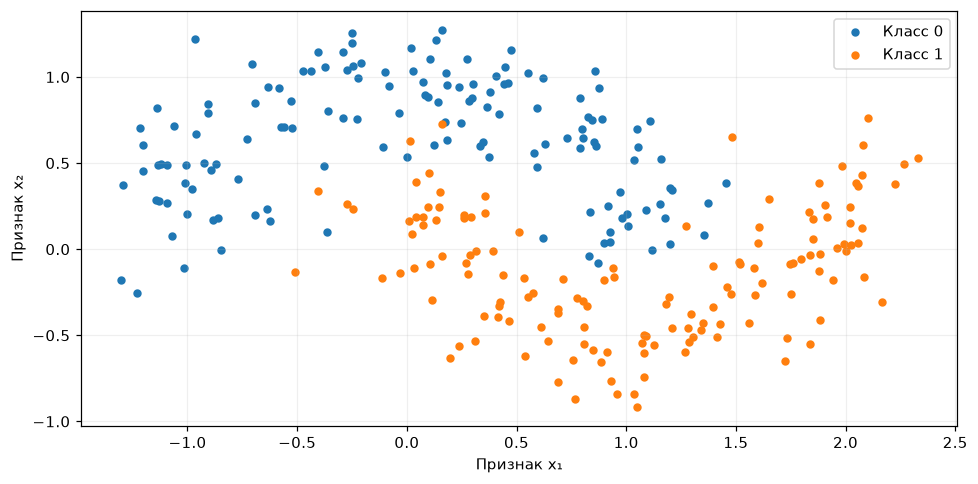

In [2]:
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
splits = cv_splits(X_train, y_train)
print('train/test:', X_train.shape, X_test.shape)
print('Классы train/test:', np.bincount(y_train), np.bincount(y_test))
for label in [0, 1]:
    plt.scatter(*X_train[y_train == label].T, s=20, label=f'Класс {label}')
plt.xlabel('Признак x₁'); plt.ylabel('Признак x₂'); plt.legend()
savefig('tree_data')

## Реализация дерева вручную
Реализовано жадное бинарное дерево: выбирается порог между соседними уникальными
значениями, минимизирующий взвешенную нечистоту дочерних узлов. Gini:
$1-\sum_c p_c^2$; entropy и log_loss: $-\sum_c p_c\log_2 p_c$.
Учитываются глубина, минимальные размеры листа и разделяемого узла. Нет
допустимого разбиения — создаётся лист большинства. Повторный train строит новое
дерево. Ничья большинства разрешается выбором меньшей метки.

Исходный критерий сопоставлял стороне порога фиксированную метку 0/1 и не
вычислял нечистоту поддеревьев; он заменён на критерий CART. Параметр n_intervals
сохранён для совместимости, но сетка интервалов не используется: пороги точные.

In [3]:
class DecisionTree:
    def __init__(self, n_intervals=10, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, criterion='gini'):
        self.n_intervals = n_intervals
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion
        if criterion not in ['gini', 'entropy', 'log_loss']:
            raise ValueError('Неизвестный критерий')
        if max_depth is not None and (not isinstance(max_depth, int) or max_depth < 1):
            raise ValueError('max_depth должен быть положительным целым или None')
        if (not isinstance(min_samples_leaf, int) or min_samples_leaf < 1 or
            not isinstance(min_samples_split, int) or min_samples_split < 2):
            raise ValueError('Неверные ограничения размеров узла')
        self.node = None

    def train(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y)
        if X.ndim != 2 or X.shape[1] == 0 or y.ndim != 1 or len(X) != len(y) or len(y) == 0:
            raise ValueError('Нужны непустые согласованные X, y')
        if not np.isfinite(X).all():
            raise ValueError('Нужны конечные признаки')
        self.classes_, encoded = np.unique(y, return_inverse=True)
        self.n_features_ = X.shape[1]
        self.node = self._split(X, encoded, 0)
        return self

    fit = train

    def _impurity(self, y):
        probabilities = np.bincount(y, minlength=len(self.classes_)) / len(y)
        probabilities = probabilities[probabilities > 0]
        if self.criterion == 'gini':
            return 1 - np.sum(probabilities ** 2)
        return -np.sum(probabilities * np.log2(probabilities))

    def _split(self, X, y, depth):
        value = int(np.argmax(np.bincount(y, minlength=len(self.classes_))))
        node = {'value': value, 'samples': len(y), 'depth': depth}
        if (np.unique(y).size == 1 or len(y) < self.min_samples_split or
            len(y) < 2 * self.min_samples_leaf or
            (self.max_depth is not None and depth >= self.max_depth)):
            return node
        best_error = self._impurity(y)
        split = None
        for feature in range(X.shape[1]):
            values = np.unique(X[:, feature])
            for threshold in (values[:-1] + values[1:]) / 2:
                left = X[:, feature] < threshold
                n_left, n_right = left.sum(), (~left).sum()
                if min(n_left, n_right) < self.min_samples_leaf:
                    continue
                error = (n_left * self._impurity(y[left]) + n_right * self._impurity(y[~left])) / len(y)
                if split is None or error < best_error - 1e-12:
                    best_error, split = error, (feature, threshold, left)
        if split is None:
            return node
        feature, threshold, left = split
        node.update(feature=feature, threshold=float(threshold),
                    left=self._split(X[left], y[left], depth + 1),
                    right=self._split(X[~left], y[~left], depth + 1))
        return node

    def predict(self, X):
        if self.node is None:
            raise ValueError('Сначала обучите дерево')
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != self.n_features_ or not np.isfinite(X).all():
            raise ValueError('Неверные признаки для predict')
        output = []
        for point in X:
            node = self.node
            while 'feature' in node:
                node = node['left'] if point[node['feature']] < node['threshold'] else node['right']
            output.append(self.classes_[node['value']])
        return np.array(output, dtype=self.classes_.dtype)

manual = DecisionTree().train(X_train, y_train)
manual_scores = scores(y_test, manual.predict(X_test))
print('Ручное дерево:', manual_scores)

# Проверки заведомо известных ответов и ограничений структуры.
np.testing.assert_array_equal(DecisionTree().train([[0], [1], [2], [3]], [0, 0, 1, 1]).predict([[0.2], [2.8]]), [0, 1])
np.testing.assert_array_equal(DecisionTree().train([[1], [1], [1]], [0, 1, 1]).predict([[1]]), [1])
np.testing.assert_array_equal(DecisionTree().train([[0], [1]], [7, 7]).predict([[3]]), [7])
np.testing.assert_array_equal(DecisionTree().train([[0], [1], [2], [3], [4], [5]], [2, 2, 4, 4, 8, 8]).predict([[0], [2], [5]]), [2, 4, 8])
reused = DecisionTree().train([[0], [1]], [0, 1]).train([[0], [1]], [1, 1])
np.testing.assert_array_equal(reused.predict([[0], [1]]), [1, 1])
constrained = DecisionTree(max_depth=3, min_samples_leaf=5).train(X_train, y_train)
def check_nodes(node):
    assert node['depth'] <= 3
    if 'feature' not in node:
        assert node['samples'] >= 5
    else:
        check_nodes(node['left']); check_nodes(node['right'])
check_nodes(constrained.node)
# CART допускает нулевой прирост на промежуточном уровне (пример XOR).
xor_X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_y = np.array([0, 1, 1, 0])
np.testing.assert_array_equal(DecisionTree().train(xor_X, xor_y).predict(xor_X), xor_y)
check_rows = []
for criterion in ['gini', 'entropy', 'log_loss']:
    own = DecisionTree(max_depth=3, criterion=criterion).train(X_train, y_train)
    ref = DecisionTreeClassifier(max_depth=3, criterion=criterion, random_state=42).fit(X_train, y_train)
    agreement = np.mean(own.predict(X_test) == ref.predict(X_test))
    check_rows.append({'criterion': criterion, 'agreement': agreement,
                       'manual_accuracy': accuracy_score(y_test, own.predict(X_test)),
                       'sklearn_accuracy': accuracy_score(y_test, ref.predict(X_test))})
    # Корневой лучший сплит на этих данных уникален; сравниваем с sklearn.
    assert own.node['feature'] == ref.tree_.feature[0]
    assert abs(own.node['threshold'] - ref.tree_.threshold[0]) < 1e-6
display(table(pd.DataFrame(check_rows), 'tree_manual_checks'))
print('Граничные случаи, ограничения и корневые разбиения: OK')

Ручное дерево: {'accuracy': 0.9416666666666667, 'f1': 0.9401709401709402}


,criterion,agreement,manual_accuracy,sklearn_accuracy
0,gini,1.0,0.883333,0.883333
1,entropy,1.0,0.883333,0.883333
2,log_loss,1.0,0.883333,0.883333


Граничные случаи, ограничения и корневые разбиения: OK


## Подбор всех параметров
Полная сетка: глубины 1, 3, 5, 8, 12, 20, None; три критерия; два splitter;
min_samples_leaf = 1, 3, 5, 10; min_samples_split = 2, 5, 10;
max_features = None, sqrt, log2, 0.25, 0.5. Всего 2520 конфигураций × 15 фолдов.
Для основного сравнения случайность дерева зафиксирована: random_state=42.
При полной ничьей остаётся первый вариант сетки: меньшая глубина, gini, best.

In [4]:
DEPTHS = [1, 3, 5, 8, 12, 20, None]
FEATURES = {'None': None, 'sqrt': 'sqrt', 'log2': 'log2', '0.25': 0.25, '0.5': 0.5}
configs, rows = [], []
for depth, criterion, splitter, leaf, split, feature_label in product(
        DEPTHS, ['gini', 'entropy', 'log_loss'], ['best', 'random'],
        [1, 3, 5, 10], [2, 5, 10], FEATURES):
    params = dict(max_depth=depth, criterion=criterion, splitter=splitter,
                  min_samples_leaf=leaf, min_samples_split=split,
                  max_features=FEATURES[feature_label], random_state=42)
    result = evaluate_cv(lambda fit: DecisionTreeClassifier(**params), X_train, y_train, splits)
    configs.append(params)
    rows.append({'config_id': len(configs)-1, 'max_depth': 'None' if depth is None else str(depth),
                 'criterion': criterion, 'splitter': splitter, 'min_samples_leaf': leaf,
                 'min_samples_split': split, 'max_features': feature_label, **result})
results = table(pd.DataFrame(rows), 'tree_grid')
ranked = results.sort_values(['cv_accuracy_mean', 'cv_f1_mean', 'cv_accuracy_std'],
                             ascending=[False, False, True], kind='stable')
winner = ranked.iloc[0]
best_params = configs[int(winner.config_id)]
print('Конфигураций:', len(results), 'Обучений:', len(results) * len(splits))
print('Выбрано по CV:', best_params)
display(ranked.head(10).round(5))

Конфигураций: 2520 Обучений: 37800
Выбрано по CV: {'max_depth': 12, 'criterion': 'gini', 'splitter': 'random', 'min_samples_leaf': 1, 'min_samples_split': 5, 'max_features': None, 'random_state': 42}


,config_id,max_depth,criterion,splitter,min_samples_leaf,min_samples_split,max_features,train_accuracy_mean,train_f1_mean,cv_accuracy_mean,cv_f1_mean,train_accuracy_std,train_f1_std,cv_accuracy_std,cv_f1_std
1505,1505,12,gini,random,1,5,None,0.97560,0.97527,0.95357,0.95321,0.00581,0.00586,0.02415,0.02390
1625,1625,12,entropy,random,1,5,None,0.97470,0.97438,0.95238,0.95012,0.00729,0.00726,0.03798,0.04168
1745,1745,12,log_loss,random,1,5,None,0.97470,0.97438,0.95238,0.95012,0.00729,0.00726,0.03798,0.04168
1865,1865,20,gini,random,1,5,None,0.97619,0.97590,0.95119,0.95107,0.00646,0.00653,0.02654,0.02638
2225,2225,None,gini,random,1,5,None,0.97619,0.97590,0.95119,0.95107,0.00646,0.00653,0.02654,0.02638
840,840,5,entropy,best,1,2,None,0.98929,0.98922,0.95119,0.94988,0.00440,0.00445,0.02184,0.02313
845,845,5,entropy,best,1,5,None,0.98899,0.98893,0.95119,0.94988,0.00442,0.00447,0.02184,0.02313
960,960,5,log_loss,best,1,2,None,0.98929,0.98922,0.95119,0.94988,0.00440,0.00445,0.02184,0.02313
965,965,5,log_loss,best,1,5,None,0.98899,0.98893,0.95119,0.94988,0.00442,0.00447,0.02184,0.02313
1510,1510,12,gini,random,1,10,None,0.95863,0.95816,0.95000,0.94926,0.01268,0.01269,0.02799,0.02862


,max_depth,train_accuracy_mean,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
0,1,0.8321,0.7988,0.0479,0.8045
360,3,0.9140,0.8893,0.0303,0.8926
720,5,0.9893,0.9417,0.0320,0.9401
1080,8,1.0000,0.9381,0.0337,0.9377
1440,12,1.0000,0.9381,0.0337,0.9377
1800,20,1.0000,0.9381,0.0337,0.9377
2160,None,1.0000,0.9381,0.0337,0.9377


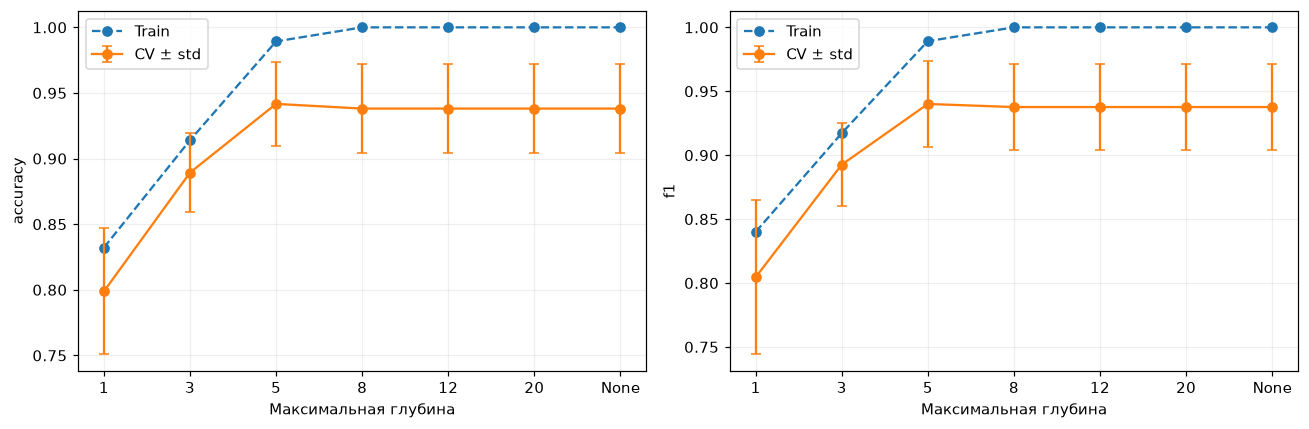

,criterion,splitter,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
720,gini,best,0.9417,0.0320,0.9401
780,gini,random,0.9131,0.0356,0.9059
840,entropy,best,0.9512,0.0218,0.9499
900,entropy,random,0.8952,0.0323,0.8828
960,log_loss,best,0.9512,0.0218,0.9499
1020,log_loss,random,0.8952,0.0323,0.8828


,min_samples_leaf,min_samples_split,train_accuracy_mean,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
2160,1,2,1.0000,0.9381,0.0337,0.9377
2165,1,5,0.9932,0.9369,0.0343,0.9362
2170,1,10,0.9890,0.9345,0.0380,0.9344
2175,3,2,0.9833,0.9417,0.0327,0.9413
2180,3,5,0.9833,0.9417,0.0327,0.9413
2185,3,10,0.9815,0.9381,0.0369,0.9381
2190,5,2,0.9780,0.9369,0.0404,0.9372
2195,5,5,0.9780,0.9369,0.0404,0.9372
2200,5,10,0.9780,0.9369,0.0404,0.9372
2205,10,2,0.9622,0.9250,0.0365,0.9232


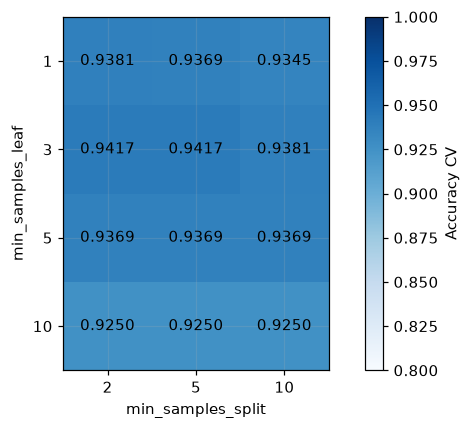

,max_features,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
720,None,0.9417,0.0320,0.9401
721,sqrt,0.8952,0.0556,0.8966
722,log2,0.8952,0.0556,0.8966
723,0.25,0.8952,0.0556,0.8966
724,0.5,0.8952,0.0556,0.8966


In [5]:
depth_table = table(results[(results.criterion == 'gini') & (results.splitter == 'best') &
                            (results.min_samples_leaf == 1) & (results.min_samples_split == 2) &
                            (results.max_features == 'None')], 'tree_depth')
display(depth_table[['max_depth', 'train_accuracy_mean', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_mean']].round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, measure in zip(axes, ['accuracy', 'f1']):
    ax.plot(range(len(depth_table)), depth_table[f'train_{measure}_mean'], 'o--', label='Train')
    ax.errorbar(range(len(depth_table)), depth_table[f'cv_{measure}_mean'],
                yerr=depth_table[f'cv_{measure}_std'], marker='o', capsize=3, label='CV ± std')
    ax.set_xticks(range(len(depth_table)), depth_table.max_depth)
    ax.set(xlabel='Максимальная глубина', ylabel=measure); ax.legend()
savefig('tree_depth')

criterion_table = table(results[(results.max_depth == '5') & (results.min_samples_leaf == 1) &
                                 (results.min_samples_split == 2) & (results.max_features == 'None')], 'tree_criteria')
display(criterion_table[['criterion', 'splitter', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_mean']].round(4))
regularizer_table = table(results[(results.max_depth == 'None') & (results.criterion == 'gini') &
                                   (results.splitter == 'best') & (results.max_features == 'None')], 'tree_regularizers')
display(regularizer_table[['min_samples_leaf', 'min_samples_split', 'train_accuracy_mean',
                           'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_mean']].round(4))
pivot = regularizer_table.pivot(index='min_samples_leaf', columns='min_samples_split', values='cv_accuracy_mean')
fig, ax = plt.subplots(figsize=(7, 4))
heat = ax.imshow(pivot, vmin=0.8, vmax=1, cmap='Blues')
for i, row in enumerate(pivot.to_numpy()):
    for j, value in enumerate(row):
        ax.text(j, i, f'{value:.4f}', ha='center', va='center', color='black')
ax.set_xticks(range(len(pivot.columns)), pivot.columns); ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set(xlabel='min_samples_split', ylabel='min_samples_leaf')
fig.colorbar(heat, ax=ax, label='Accuracy CV')
savefig('tree_regularizers')
feature_table = table(results[(results.max_depth == '5') & (results.criterion == 'gini') &
                               (results.splitter == 'best') & (results.min_samples_leaf == 1) &
                               (results.min_samples_split == 2)], 'tree_features')
display(feature_table[['max_features', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_mean']].round(4))

## Устойчивость и чувствительность к шуму
Сначала изолируется случайность splitter: на одном train и тех же фолдах
сравниваются 20 значений random_state. Затем проводится парный опыт с
изменёнными метками. Он позволяет отделить разброс из-за seed от устойчивости
к повреждению обучающих данных.

,splitter,accuracy_mean,accuracy_std_between_seeds,f1_mean
0,best,0.94196,0.00053,0.94035
1,random,0.87607,0.03396,0.87796


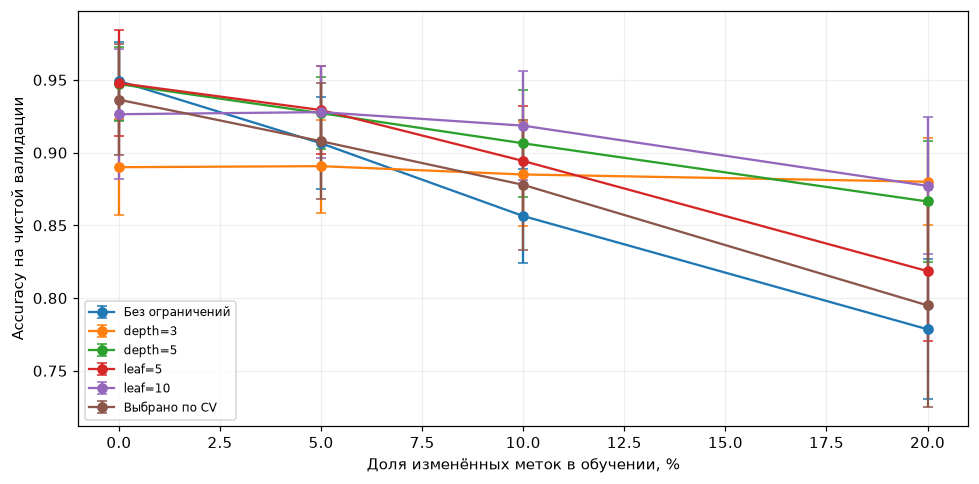

,model,noise,accuracy_mean,accuracy_std,f1_mean,f1_std,disagreement_mean
0,Без ограничений,0.00,0.9493,0.0268,0.9491,0.0268,0.0000
1,Без ограничений,0.05,0.9064,0.0316,0.9065,0.0311,0.0643
2,Без ограничений,0.10,0.8564,0.0323,0.8599,0.0304,0.1214
3,Без ограничений,0.20,0.7786,0.0481,0.7790,0.0483,0.2136
4,depth=3,0.00,0.8900,0.0328,0.8913,0.0366,0.0000
5,depth=3,0.05,0.8907,0.0319,0.8929,0.0307,0.0293
6,depth=3,0.10,0.8850,0.0357,0.8885,0.0375,0.0464
7,depth=3,0.20,0.8800,0.0298,0.8833,0.0271,0.0571
8,depth=5,0.00,0.9471,0.0254,0.9467,0.0257,0.0000
9,depth=5,0.05,0.9271,0.0249,0.9270,0.0242,0.0429


In [6]:
seed_rows = []
for splitter, seed in product(['best', 'random'], range(20)):
    values = evaluate_cv(lambda fit: DecisionTreeClassifier(max_depth=5, splitter=splitter,
                         random_state=seed), X_train, y_train, splits)
    seed_rows.append({'splitter': splitter, 'seed': seed, **values})
seed_raw = table(pd.DataFrame(seed_rows), 'tree_seeds_raw')
seed_summary = table(seed_raw.groupby('splitter').agg(
    accuracy_mean=('cv_accuracy_mean', 'mean'),
    accuracy_std_between_seeds=('cv_accuracy_mean', 'std'),
    f1_mean=('cv_f1_mean', 'mean')).reset_index(), 'tree_seeds')
display(seed_summary.round(5))
noise = noise_experiment({
    'Без ограничений': lambda fit, seed: DecisionTreeClassifier(random_state=seed),
    'depth=3': lambda fit, seed: DecisionTreeClassifier(max_depth=3, random_state=seed),
    'depth=5': lambda fit, seed: DecisionTreeClassifier(max_depth=5, random_state=seed),
    'leaf=5': lambda fit, seed: DecisionTreeClassifier(min_samples_leaf=5, random_state=seed),
    'leaf=10': lambda fit, seed: DecisionTreeClassifier(min_samples_leaf=10, random_state=seed),
    'Выбрано по CV': lambda fit, seed: DecisionTreeClassifier(**{**best_params, 'random_state': seed}),
}, X_train, y_train, 'tree_noise')
display(noise.round(4))

## Итоговая оценка
Параметры выбраны по CV. Рисунки ниже показывают границы решений на test и
верхние четыре уровня выбранного дерева (продолжение обозначено многоточием). Число признаков равно двум: None разрешает
оба, а sqrt, log2, 0.25 и 0.5 дают один признак на узел (округление вниз, минимум 1).
При одинаковом seed эти четыре настройки здесь эквивалентны.

,model,accuracy,f1
0,Ручное дерево,0.941667,0.940171
1,sklearn без ограничений,0.941667,0.940171
2,Выбрано по CV,0.966667,0.965517


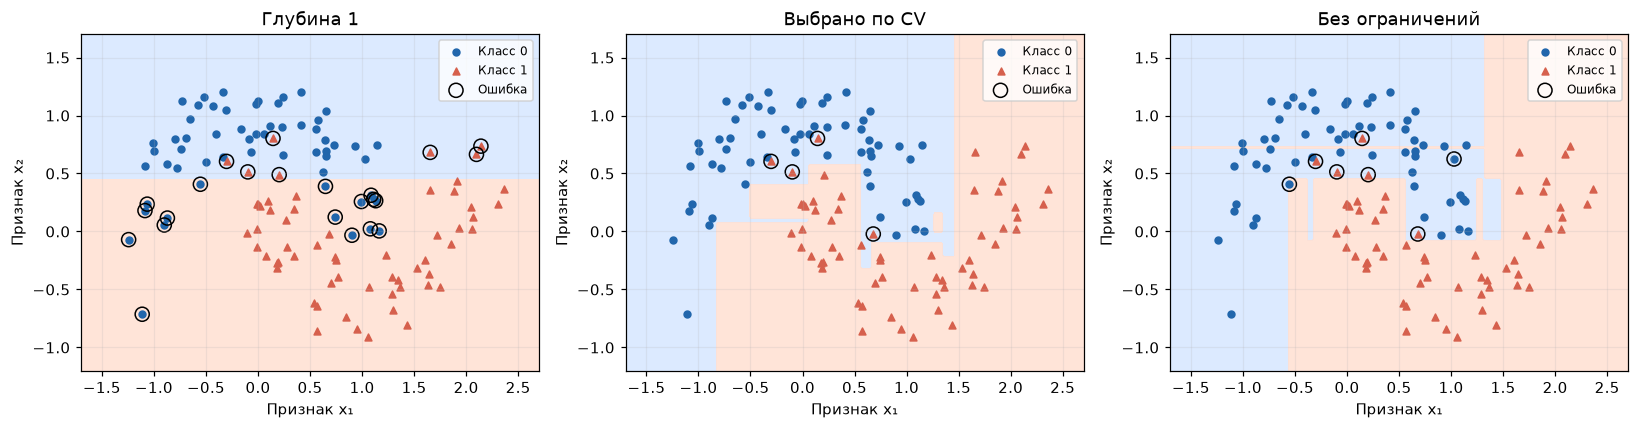

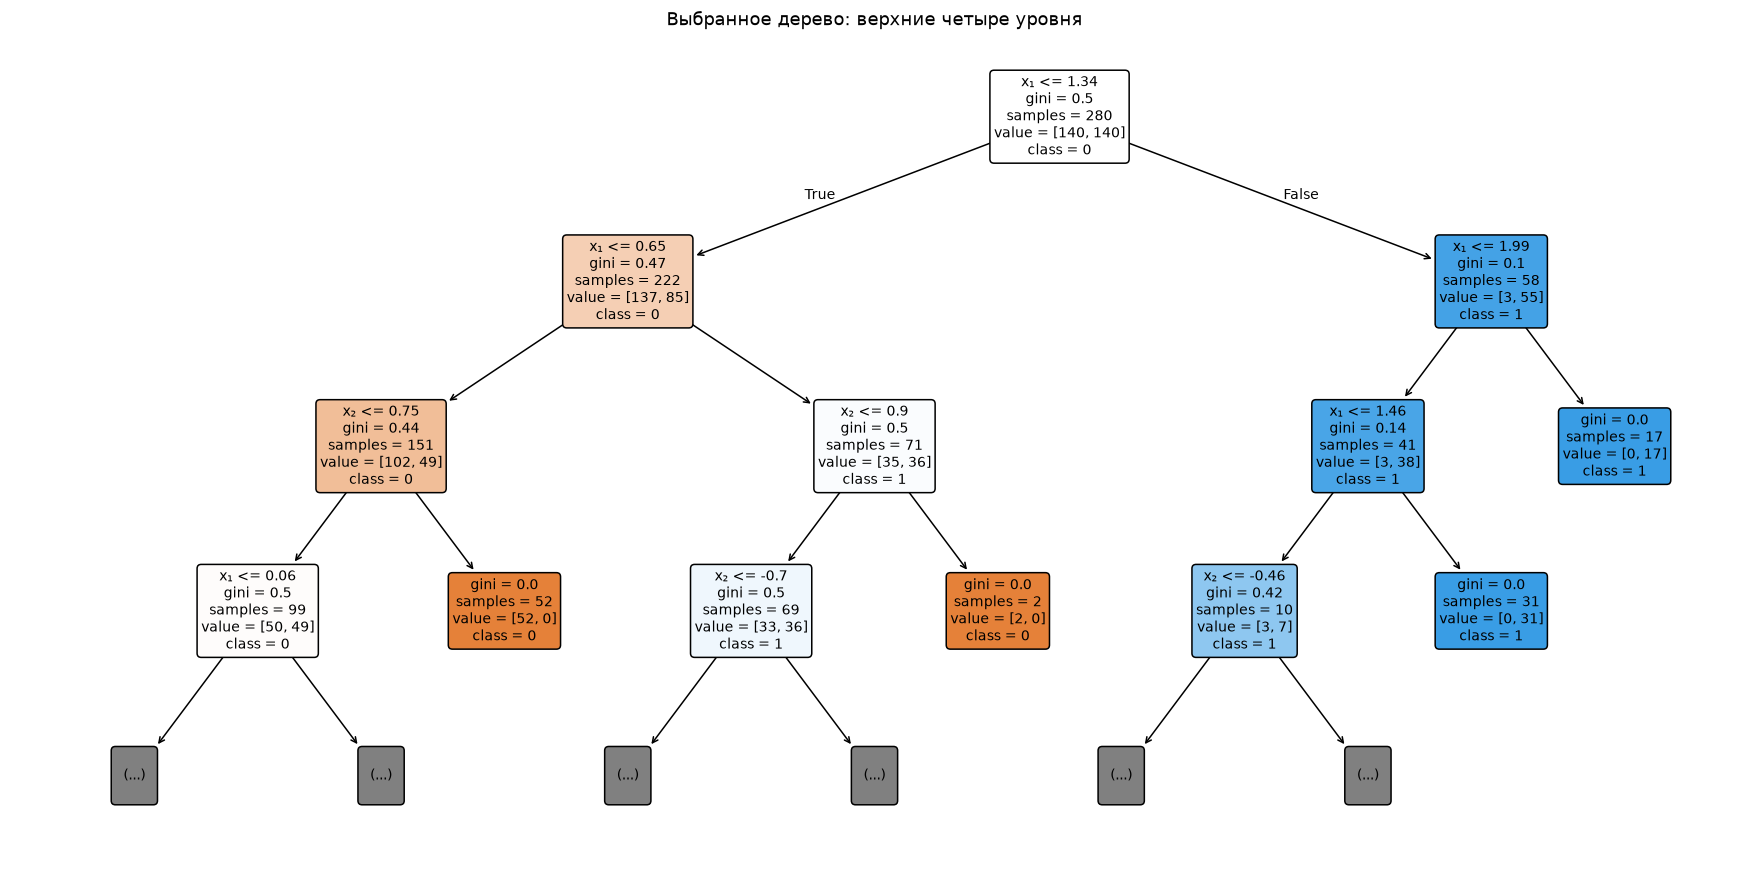

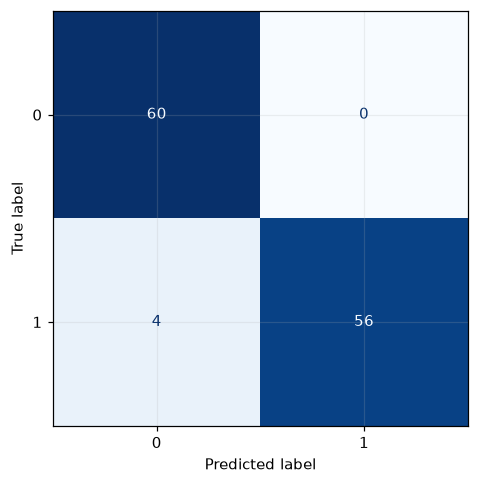

In [7]:
best_model = DecisionTreeClassifier(**best_params).fit(X_train, y_train)
baseline = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
best_test = scores(y_test, best_model.predict(X_test))
display(table(pd.DataFrame([
    {'model': 'Ручное дерево', **manual_scores},
    {'model': 'sklearn без ограничений', **scores(y_test, baseline.predict(X_test))},
    {'model': 'Выбрано по CV', **best_test},
]), 'tree_test'))
boundaries({'Глубина 1': DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train, y_train),
            'Выбрано по CV': best_model,
            'Без ограничений': baseline}, X_test, y_test, 'tree_boundaries')
plt.figure(figsize=(16, 8))
plot_tree(best_model, feature_names=['x₁', 'x₂'], class_names=['0', '1'],
          filled=True, rounded=True, fontsize=9, precision=2, max_depth=3)
plt.title('Выбранное дерево: верхние четыре уровня')
savefig('tree_structure')
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues', colorbar=False)
savefig('tree_confusion')
save_json({'environment': environment(), 'best_params': best_params,
           'best_cv': {k: float(winner[k]) for k in winner.index if k.startswith('cv_')},
           'test': best_test, 'confusion': confusion_matrix(y_test, best_model.predict(X_test)).tolist(),
           'depth': int(best_model.get_depth()), 'leaves': int(best_model.get_n_leaves()),
           'baseline_depth': int(baseline.get_depth()), 'baseline_leaves': int(baseline.get_n_leaves()),
           'configurations': len(results), 'train_size': len(y_train), 'test_size': len(y_test)}, 'tree_summary')

## Ответы и вывод
Малая глубина ограничивает способность описать изгибы полумесяцев; большая
позволяет строить листья под отдельные наблюдения. Вывод об обобщении делается
по CV, а не по обучающей accuracy. Увеличение min_samples_leaf запрещает мелкие
листья, min_samples_split ограничивает деление малых узлов. Чрезмерные ограничения
тоже могут ухудшить качество.

`entropy` и `log_loss` в sklearn используют один критерий Шеннона: совпадение
результатов ожидаемо. Случайный splitter не гарантирует устойчивости одиночного
дерева — это проверено опытом по seed и отражено в отчёте. Оптимальные параметры
и численные ответы приведены выше и в `Отчёт_практическая_работа_1.md`.

Источник: [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).